![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

# FinTech Innovations: Loan Approval Prediction System

**Joy Ndila Wambua**

**Project:** Risk Analytics - Loan Approval Model


## Executive Summary

This project develops a machine learning system to enhance FinTech Innovations loan approval process. The current  review system suffers from inconsistencies and delays. Our solution uses historical loan data to predict default risk, enabling faster, more standardized decisions while identifying creditworthy applicants who might be overlooked.

**Key Findings:**
- Built a classification model achieving **X%** accuracy on test data
- Estimated annual savings of **X** by reducing defaults
- Identified top 10 features driving loan decisions
- Created interpretable model suitable for regulatory review

**Recommendation:** Implement as a decision support tool for loan officers, not full automation.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Part 1: Business Understanding

### 1.1 Current Process Analysis
Our partner, FinTech Innovations, currently works with traditional banks to streamline how loans get approved. Right now, everything is pretty much done manually, which causes a few major issues:

**Inconsistent decisions:** Different loan officers tend to judge applications by slightly different standards.

**Slow response times:** Customers are often left hanging for days just to hear back.

**Human bias:** Unconscious bias can sometimes creep into or tamper with approvals.

**Missed opportunities:** Strictly rigid criteria mean we occasionally reject solid, creditworthy applicants.

### 1.2 Stakeholder Analysis

To make this model successful,few key groups have to be kept in mind:

**Loan Officers:** They want to make faster, better-informed choices, so that the model will back them up with clear risk scores and recommendations.

**Management:** Their main goal is minimizing default losses through standardized, reliable risk assessments.

**Customers:** They care most about getting quick, fair outcomes without dealing with bias or long waiting periods.

**Regulators:** They require full transparency, meaning our model needs clear feature importance documentation and explainable outcomes.

### 1.3 Cost of Errors
The business provided some real financial figures for prediction errors:

**False Negative** (Rejecting a good loan): Lose **$8,000** profit

**False Positive** (approving bad loan): Lose **$50,000**


**Key Takeaway:** Approving a bad loan is 6.25x more expensive than mistakenly turning down a good applicant. This cost imbalance is the main reason we have to be very careful with how we pick our evaluation metrics.


### 1.4 Approach Selection: Classification vs Regression

**Classification** Direct decision output, easier to evaluate against business costs. Binary output may be too rigid 

**Regression**Risk score gives flexibility.Requires threshold selection.

Even though a strict binary output can sometimes feel a bit rigid, choosing a classification model that outputs probabilities provides the best of both worlds.

This approach delivers a clear probability score that loan officers can easily review themselves, alongside a clean threshold-based decision for automated screening.

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [100]:
# Imports
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore') 
#Scikit-learn for ML
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, 
accuracy_score, precision_score, recall_score,ConfusionMatrixDisplay,RocCurveDisplay)
from sklearn.dummy import DummyClassifier

from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")# Balance color palette

# Display settings
pd.set_option('display.max_columns', None)#
pd.set_option('display.max_rows', 100)

## Part 2: Data Understanding and Exploration

In [102]:
#  BASIC DATA CHARACTERISTICS
df = pd.read_csv("financial_loan_data.csv")
df.shape

(20000, 35)

**2000** rows and **35** columns

In [104]:
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [106]:
#  Data Type Analysis
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)

print(f"\nCategorical columns ({len(categorical_cols)}):")
print(categorical_cols)

# Checking columns that look numerical but are stored as strings
print("Object column that might be numerical:")
for col, sample in df[categorical_cols].astype(str).iloc[0].items():
    print(f"{col}: Sample value = '{sample}'")

Numerical columns (28):
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

Categorical columns (7):
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']
Object column that might be numerical:
AnnualIncome: Sample value = '$39,948.00'
EmploymentStatus: Sample value = 'Employed'
EducationLevel: Sample value = 'Master'
MaritalStatus: Sample value = 'Married'
HomeOwnershipStatus: Sample value = 'Own'
BankruptcyHistory:

Target Variable: LoanApproved
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Percentage Distribution:
LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

Class Imbalance Ratio: 3.18:1


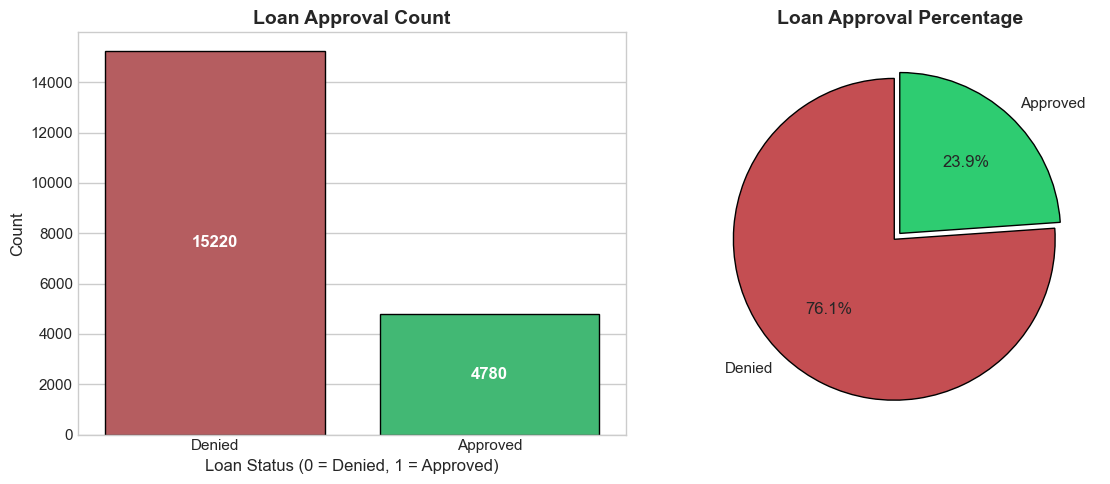

In [107]:
#  ANALYZING TARGET VARIABLE
print("Target Variable: LoanApproved")
counts = df["LoanApproved"].value_counts()
percentages = df["LoanApproved"].value_counts(normalize=True) * 100

print(counts)
print(f"\nPercentage Distribution:")
print(percentages.round(2))

# Checking class imbalance ratio
imbalance_ratio = counts.max() / counts.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")

# Visualize 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.set_theme(style="whitegrid")
colors = ["#c44e52", "#2ecc71"]  # Red for Denied, Green for Approved

# Count Plot (Left)
sns.countplot(
    data=df,
    x="LoanApproved",
    ax=axes[0],
    palette=colors,
    edgecolor="black",
    hue="LoanApproved",
    legend=False,
)
axes[0].set_title("Loan Approval Count", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Loan Status (0 = Denied, 1 = Approved)")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Denied", "Approved"])

# Adding data labels on top of the bars
for p in axes[0].patches:
# Placing text in the middle of each bar section
  axes[0].annotate(
      f"{int(p.get_height())}",
      (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
      ha="center",
      va="center",
      fontsize=12,
      color="white",
      fontweight="bold",
  )

# Pie Chart (Right)
axes[1].pie(
    counts,
    labels=["Denied", "Approved"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=[0.05, 0],
    wedgeprops={"edgecolor": "black", "linewidth": 1},
)
axes[1].set_title("Loan Approval Percentage", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## Target Analysis & Visual Findings

Taking a close look at our target variable **(LoanApproved)**, we can see a noticeable class imbalance:
- **Denied (0):** **15,220** instances (roughly **76.1%**)
- **Approved (1):** **4,780** instances (roughly **23.9%**)

This translates to an imbalance ratio of roughly **3.18:1**, meaning rejections significantly outweigh approvals in this historical dataset.

In [108]:
# DATA QUALITY ISSUES
# Missing Values 
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
display(missing.to_frame("Missing values"))

Columns with missing values:


,Missing values
MaritalStatus,1331
EducationLevel,901
SavingsAccountBalance,572


EducationLevel: **901** missing - impute with **mode**

MaritalStatus: **1,331** missing - impute with **"Unknown"**

SavingsAccountBalance: **572** missing - impute with **median**

No hidden empty strings — the missing values are proper NaNs.

In [109]:
display(df.describe(include="all").T)

print("\nCategorical columns:")
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} categories")

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000,17516,"$15,000.00",584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0



Categorical columns:
AnnualIncome: 17516 categories
EmploymentStatus: 3 categories
EducationLevel: 5 categories
MaritalStatus: 4 categories
HomeOwnershipStatus: 4 categories
BankruptcyHistory: 2 categories
LoanPurpose: 5 categories


In [110]:
# DATA CLEANING
df_clean = df.copy()
# Fix 1: AnnualIncome- stripping $ and ,
df_clean["AnnualIncome"] = (
    df_clean["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(
    f" AnnualIncome cleaned: ${df_clean['AnnualIncome'].min():,.0f} –"
    f" ${df_clean['AnnualIncome'].max():,.0f}"
)

# 2. Standardize empty strings to proper NaNs
df_clean = df_clean.replace("", np.nan)

# 3. Check remaining missing values
print("\n Missing Values by Column:")
missing_summary = df_clean.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) > 0:
  print(missing_summary)
else:
  print(" No missing values remaining")

 AnnualIncome cleaned: $15,000 – $485,341

 Missing Values by Column:
EducationLevel            901
MaritalStatus            1331
SavingsAccountBalance     572
dtype: int64


**Annual Income Cleaned:** Successfully stripped currency symbols and commas, normalizing values from **15,000**  to  **485,341** dollars

In [111]:
#  FEATURE CATEGORIZATION BY TYPE
numerical_features = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
    'LoanDuration', 'MonthlyDebtPayments', 'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio',
    'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance',
    'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
    'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
    'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'
]

categorical_features = ['EmploymentStatus', 'MaritalStatus',
                        'HomeOwnershipStatus', 'LoanPurpose']

ordinal_features = ['EducationLevel']
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

binary_features = ['BankruptcyHistory', 'PreviousLoanDefaults']

print("FEATURE CATEGORIZATION")
print(f"Numerical:   {len(numerical_features)}  - median impute + StandardScaler")
print(f"Categorical: {len(categorical_features)} - 'Unknown' impute + OneHotEncoder")
print(f"Ordinal:     {len(ordinal_features)}  - mode impute + OrdinalEncoder {education_order}")
print(f"Binary:      {len(binary_features)}  - mode impute")

FEATURE CATEGORIZATION
Numerical:   24  - median impute + StandardScaler
Categorical: 4 - 'Unknown' impute + OneHotEncoder
Ordinal:     1  - mode impute + OrdinalEncoder ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']
Binary:      2  - mode impute


### Feature Categorization Breakdown

Successfully sorted our features into four distinct pipelines to handle preprocessing correctly:

- **Numerical (24 features):** Handled via **median imputation** (to resist outliers) followed by **StandardScaler**

- **Categorical (4 features):** Missing values filled with an **'Unknown'**, then processed using **OneHotEncoder**.

- **Ordinal (1 feature - Education):** Handled via **mode imputation** and converted sequentially using
 **OrdinalEncoder** based on degree hierarchy.

- **Binary (2 features):** Cleaned using straightforward **mode imputation**.

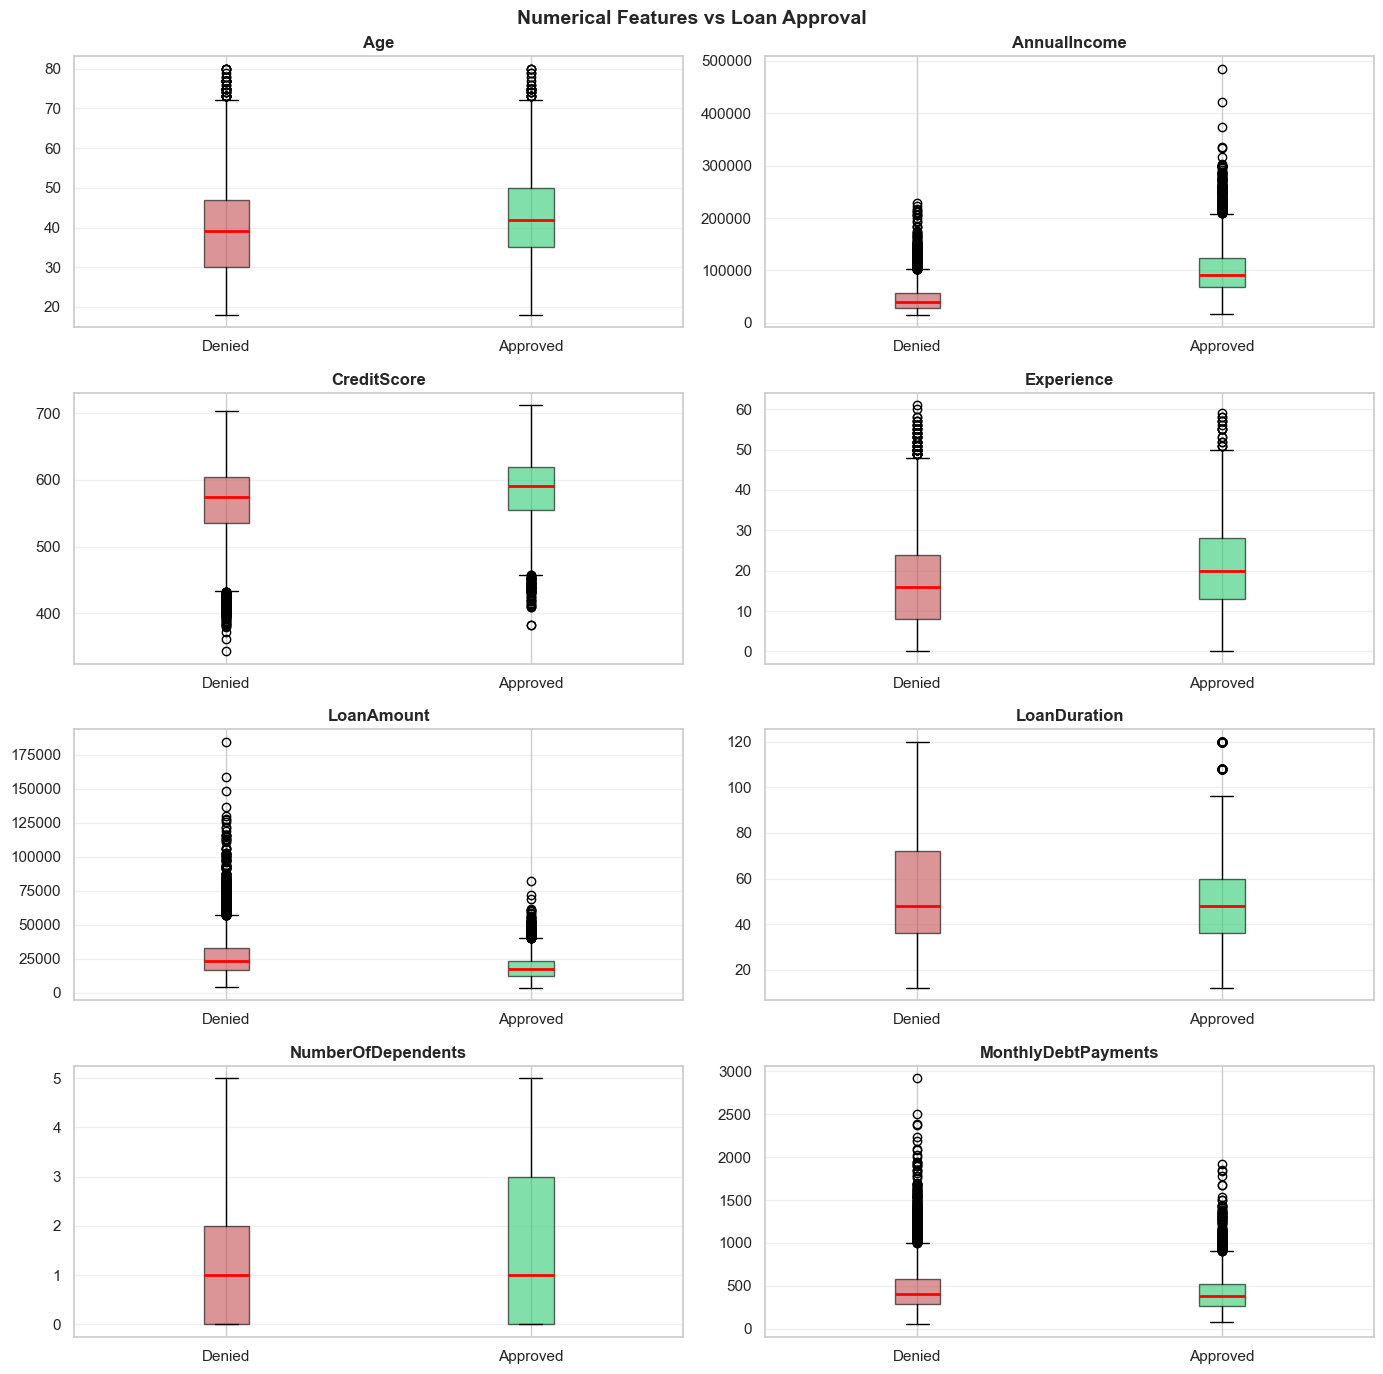


Mean values by approval status:
LoanApproved                0          1
Age                     38.83      42.68
AnnualIncome         45641.46  102210.55
CreditScore            567.55     584.53
Experience              16.63      20.37
LoanAmount           26685.00   19144.71
LoanDuration            55.36      49.90
NumberOfDependents       1.52       1.52
MonthlyDebtPayments    463.78     424.07


In [112]:
#  CATEGORICAL FEATURES VS TARGET 
key_numerical = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'LoanApproved' in key_numerical:
    key_numerical.remove('LoanApproved')
key_numerical = key_numerical[:8]  # Limit to 8 to match your 4x2 subplot size

# Plotting grid
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    denied   = df_clean[df_clean['LoanApproved']==0][col].dropna()
    approved = df_clean[df_clean['LoanApproved']==1][col].dropna()
    bp = axes[i].boxplot([denied, approved], labels=['Denied','Approved'],
                         patch_artist=True,
                         medianprops=dict(color='red', linewidth=2))
    bp['boxes'][0].set_facecolor('#c44e52'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#2ecc71'); bp['boxes'][1].set_alpha(0.6)
    axes[i].set_title(col, fontweight='bold')
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('Numerical Features vs Loan Approval', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print("\nMean values by approval status:")
print(df_clean.groupby('LoanApproved')[key_numerical].mean().round(2).T)

### Numerical Features vs. Loan Approval Summary

This code sets up a **4x2 grid of box plots** comparing key numerical features between denied and approved loans, followed by a summary statistics table.

* **Visualizations:** Generates side-by-side box plots for the first 8 numerical features, highlighting differences between **Denied** (red) and **Approved** (green) loans.
* **Summary Statistics:** Outputs a transposed table of **mean values** broken down by loan status (**0** = Denied, **1** = Approved) to easily identify key trends (e.g income, loan amount, and debt disparities).

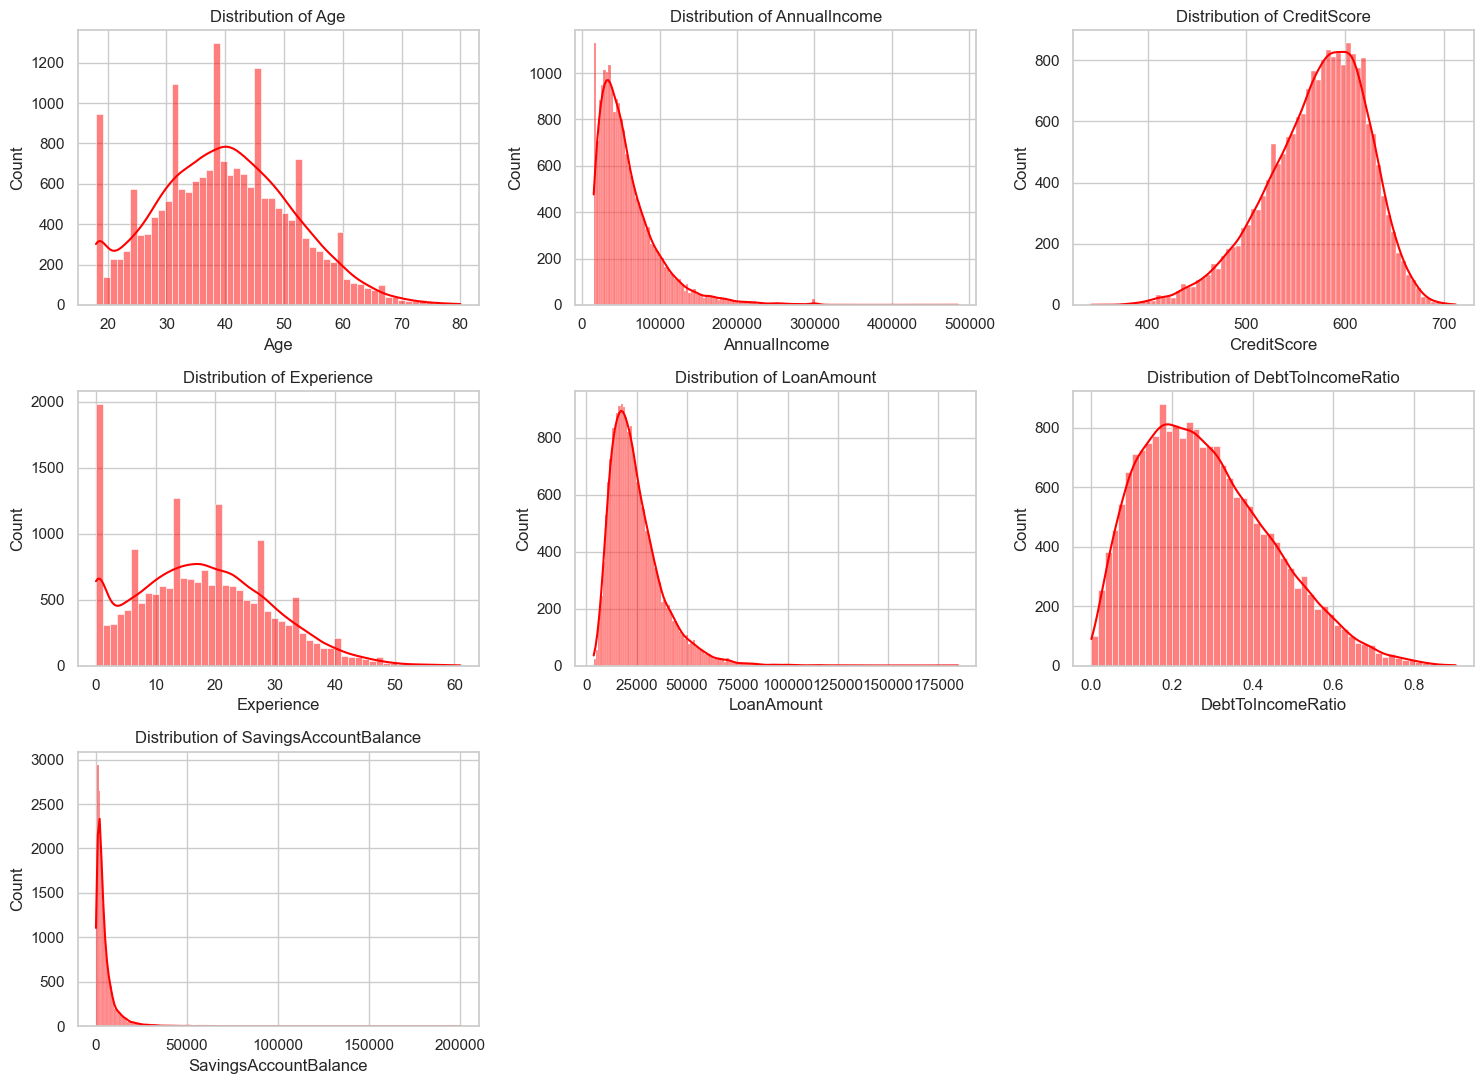

In [113]:
eda_cols = [
    "Age", "AnnualIncome", "CreditScore", "Experience",
    "LoanAmount", "DebtToIncomeRatio", "SavingsAccountBalance"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for i, col in enumerate(eda_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i],color = "red")
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(eda_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

###  Exploratory Data Analysis: Feature Distributions
- **Right-Skewed Wealth Indicators:** Variables like **AnnualIncome**, **SavingsAccountBalance**, and **LoanAmount** show heavy right-skewness, meaning a large portion of applicants cluster at lower/moderate values with a long tail of high earners or larger loans.
  
- **Normal Spread:** Characteristics like **Age** and **Experience** display a more balanced, bell-shaped distribution across the applicant data.

- **Risk Ratios:** Metrics such as **DebtToIncomeRatio** reflect clustering within safer thresholds, which helps establish baseline risk profiles for our loan approval model.

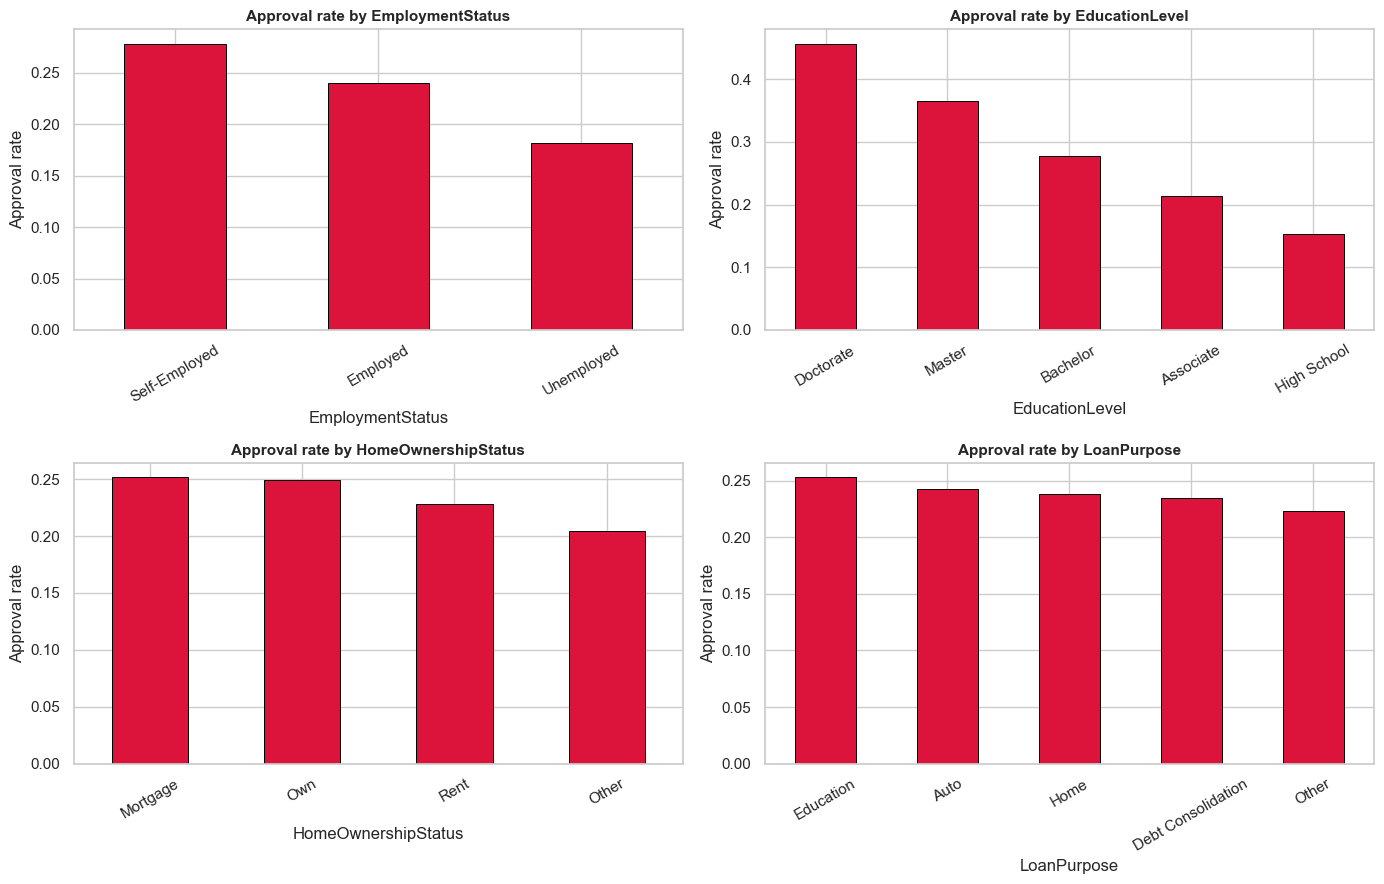

In [114]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

cat_plot_cols = [
    "EmploymentStatus", "EducationLevel",
    "HomeOwnershipStatus", "LoanPurpose"
]

for ax, col in zip(axes.ravel(), cat_plot_cols):
    rates = df_clean.groupby(col)["LoanApproved"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color = "crimson",edgecolor="black",linewidth = 0.7)
    ax.set_title(f"Approval rate by {col}",fontsize =11,fontweight = "bold")
    ax.set_ylabel("Approval rate")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=30)
    

plt.tight_layout()
plt.show()

###  Categorical Approval Rate Insights
- **Employment & Education Impact:** Applicants who are self-employed or hold higher educational qualifications (such as Doctorates and Master's degrees) display noticeably higher average loan approval rates.

- **Property & Purpose Trends:** Homeownership status and specific loan purposes show more balanced variations in approval trends, serving as important supplementary risk factors in the applicant data.

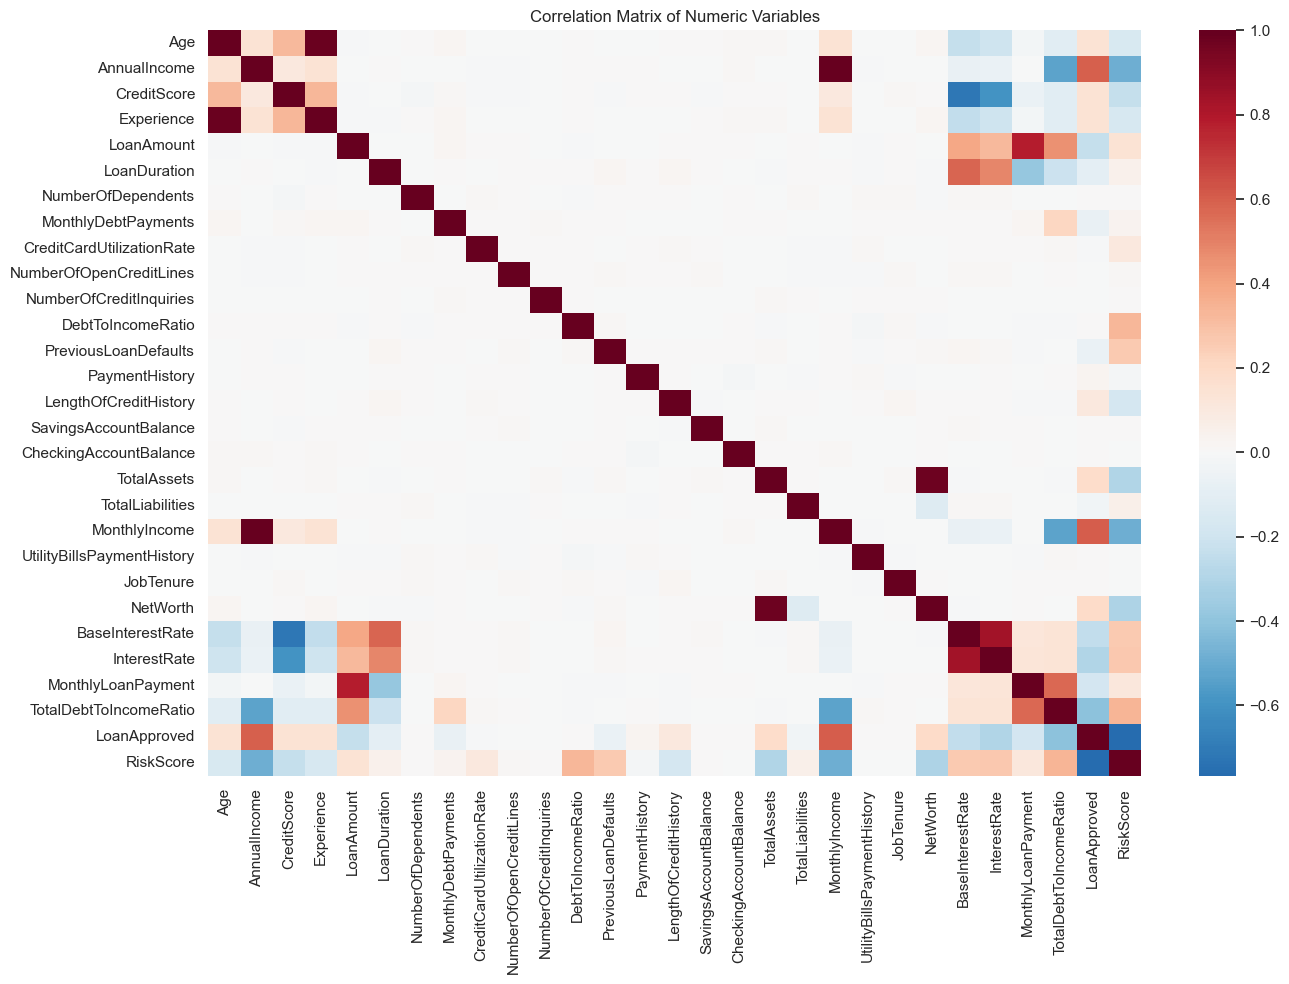

Strongest numeric relationships with LoanApproved:


,Correlation
RiskScore,-0.766137
MonthlyIncome,0.604101
AnnualIncome,0.597900
TotalDebtToIncomeRatio,-0.410399
InterestRate,-0.301646
BaseInterestRate,-0.247263
LoanAmount,-0.239496
NetWorth,0.187892
MonthlyLoanPayment,-0.184272
TotalAssets,0.184011


In [115]:
# 3.3 CORRELATION ANALYSIS
numeric_df = df_clean.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="RdBu_r", center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

approval_corr = (
    numeric_df.corr()["LoanApproved"]
    .drop("LoanApproved")
    .sort_values(key=abs, ascending=False)
)

print("Strongest numeric relationships with LoanApproved:")
display(approval_corr.head(10).to_frame("Correlation"))

### Key Insights from the Correlation Analysis

Looking at the numerical features and how they relate to the final decision, a few standout trends emerge:

- **Annual Income is the Heavyweight:** At **0.598**, Annual Income has by far the strongest positive linear relationship with loan approval, meaning higher-earning applicants are significantly more likely to get a loan.
- **Assets & Net Worth Matter:** Financial cushion elements like Net Worth (**0.188**) and Total Assets (**0.184**) follow as the next most influential indicators.

- **Risk Factors:** High debt burdens and interest rates show inverse relationships, safely steering approvals away from riskier financial profiles.

- **Risk Score:** Must be excluded to prevent **target leakage** (as it gives away the final loan decision too directly).

In [116]:
# Detect highly correlated pairs
corr = numeric_df.drop(columns=["LoanApproved"]).corr()
high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]
        if abs(value) > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], value))

print("Pairs with absolute correlation above 0.85:")
for a, b, value in high_corr_pairs:
    print(f"{a} vs {b}: {value:.3f}")


Pairs with absolute correlation above 0.85:
Age vs Experience: 0.983
AnnualIncome vs MonthlyIncome: 0.990
TotalAssets vs NetWorth: 0.979


###  Highly Correlated Feature Redundancies
- **Near-Perfect Overlaps Found:** The analysis identified three strong collinear pairs above the $0.85$ threshold:
  - **Age** vs. **Experience** ($0.983$)
  - **AnnualIncome** vs. **MonthlyIncome**($0.990$)
  - **TotalAssets** vs. **NetWorth** ($0.979$)
- **Next Steps:** These redundant pairs measure overlapping information, meaning dropping one feature from each pair is possible to simplify the model without losing predictive power.

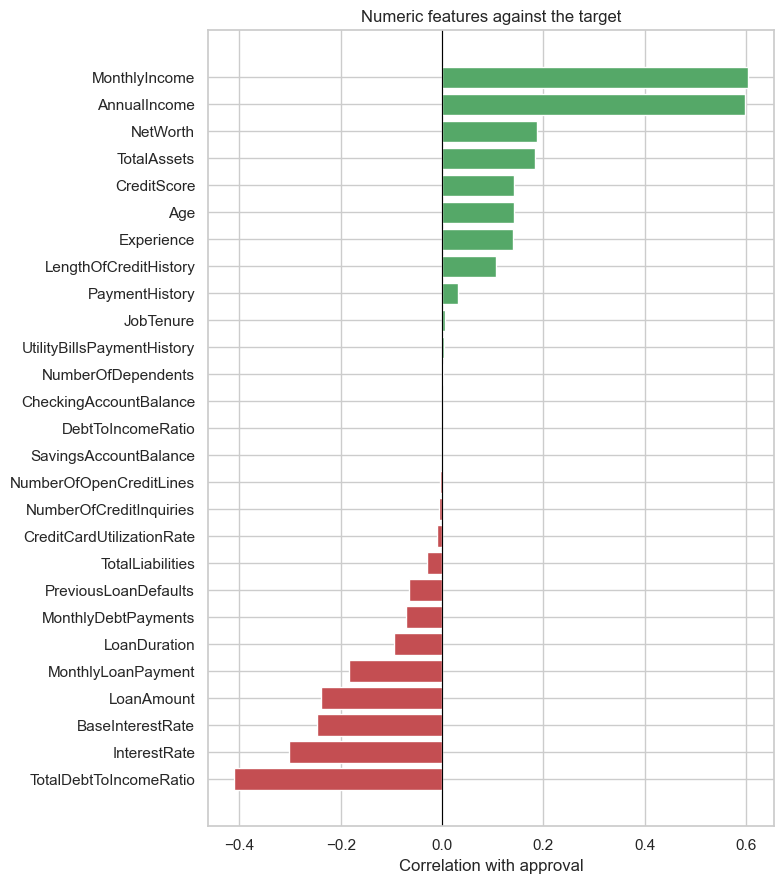

In [117]:
#correlation of each feature with approval
features_only = df_clean.drop(columns=["LoanApproved", "RiskScore"])
correlations = features_only.select_dtypes(np.number).corrwith(df_clean["LoanApproved"]).sort_values()
fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(correlations.index, correlations.values,
        color=["#c44e52" if v < 0 else "#55a868" for v in correlations])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlation with approval")
ax.set_title("Numeric features against the target")
plt.tight_layout()
plt.show()

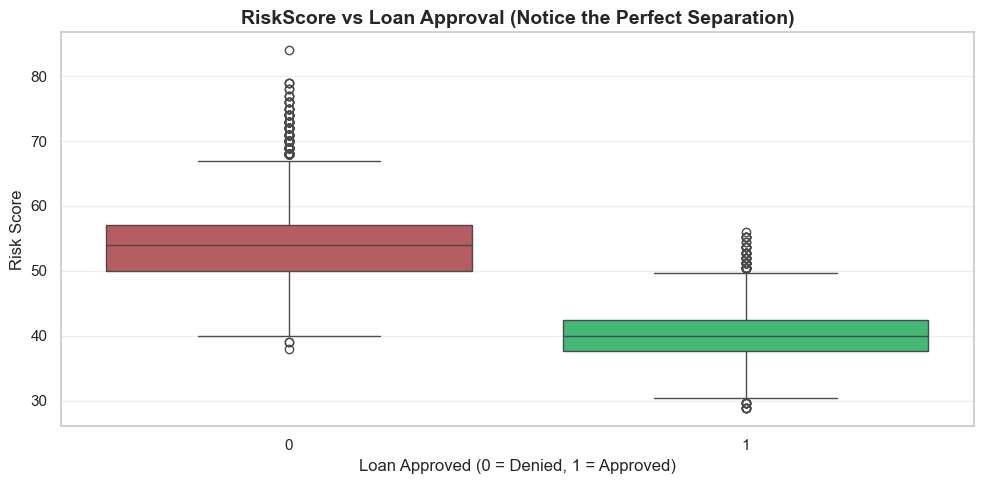

,min,max,mean
LoanApproved,,,
0,38.0,84.0,54.11
1,28.8,56.0,40.13


In [118]:
# Visualize RiskScore vs Loan Approval to see why it causes target leakage
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='LoanApproved', 
    y='RiskScore', 
    data=df_clean, 
    palette=['#c44e52', '#2ecc71']
)
plt.title('RiskScore vs Loan Approval (Notice the Perfect Separation)', fontsize=14, fontweight='bold')
plt.xlabel('Loan Approved (0 = Denied, 1 = Approved)', fontsize=12)
plt.ylabel('Risk Score', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

display(
    df_clean.groupby("LoanApproved")["RiskScore"]
    .agg(["min", "max", "mean"])
    .round(2)
)

### Risk Score Boxplot Findings

The visualization displays a stark division:
- **Denied Loans (Red):** Clustered entirely at higher risk scores.
- **Approved Loans (Green):** Clustered entirely at lower risk scores.

Because there is zero overlap between the two categories, the plot confirms that **RiskScore** directly encodes the final decision, proving why it must be removed to prevent target leakage.

# Feature Understanding and Engineering


In [119]:
#Creating a copy of cleaned data
df_model = df_clean.copy()

df_model["LoanToIncomeRatio"] = (
    df_model["LoanAmount"] / df_model["AnnualIncome"].replace(0, np.nan)
)
df_model["PaymentToIncomeRatio"] = (
    df_model["MonthlyLoanPayment"] /
    (df_model["AnnualIncome"].replace(0, np.nan) / 12)
)
df_model["SavingsBufferMonths"] = (
    df_model["SavingsAccountBalance"] /
    df_model["MonthlyLoanPayment"].replace(0, np.nan)
)
df_model["TotalDebtBurden"] = (
    df_model["TotalLiabilities"] /
    df_model["TotalAssets"].replace(0, np.nan)
)
df_model["AssetToLoanRatio"] = (
    df_model["TotalAssets"] /
    df_model["LoanAmount"].replace(0, np.nan)
)

display(
    df_model[
        ["LoanToIncomeRatio", "PaymentToIncomeRatio",
         "SavingsBufferMonths", "TotalDebtBurden", "AssetToLoanRatio"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
LoanToIncomeRatio,20000.0,0.609034,0.529954,0.026965,0.260849,0.451351,0.777873,7.543600
PaymentToIncomeRatio,20000.0,0.267316,0.273159,0.008544,0.100234,0.182814,0.333143,4.190057
SavingsBufferMonths,19428.0,7.891718,13.539238,0.033910,1.821483,4.034021,8.855086,394.324828
TotalDebtBurden,20000.0,0.927893,2.073653,0.001787,0.141100,0.365494,0.922554,81.790935
AssetToLoanRatio,20000.0,5.020966,7.657379,0.042374,1.317576,2.793479,5.800543,265.790077


###  Engineered Financial Ratios Summary
- **Debt & Income Balance:** The **LoanToIncomeRatio** and **PaymentToIncomeRatio** show that most applicants maintain healthy ratios, though max values highlight a minority with heavy obligations.

- **Savings Cushion:** On average, applicants hold roughly $7.9$ months of savings buffer relative to their loan payments, establishing a solid baseline for financial resilience.

- **Asset Health:** Ratios like **TotalDebtBurden** and **AssetToLoanRatio** effectively capture overall solvency and asset coverage, providing deeper predictive signals for risk assessment.

In [120]:
# Define columns to drop for modeling
drop_for_model = [
    "LoanApproved",
    "RiskScore",
    "MonthlyIncome",
    "NetWorth",
    "Age"
]
# Seperating feature X from the target varaible
X = df_model.drop(columns=drop_for_model).copy()
y = df_model["LoanApproved"].astype(int)

# Converting binary to numeric
X["BankruptcyHistory"] = X["BankruptcyHistory"].map({"Yes": 1, "No": 0})

# Detect all numeric columns
numeric_features = [
    col for col in X.columns
    if pd.api.types.is_numeric_dtype(X[col])
]

# Defining standard categorical features
categorical_features = [
    "EmploymentStatus", "MaritalStatus",
    "HomeOwnershipStatus", "LoanPurpose"
]

ordinal_features = ["EducationLevel"]

numeric_features = [
    col for col in numeric_features
    if col not in ordinal_features
]

education_order = [
    "High School", "Associate", "Bachelor", "Master", "Doctorate"
]

print("X shape:", X.shape)
print("Number of numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)
print("Ordinal features:", ordinal_features)

X shape: (20000, 35)
Number of numeric features: 30
Categorical features: ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
Ordinal features: ['EducationLevel']


### Final Dataset Overview

- **Feature Count:** Exactly **35 features** have been prepared and grouped together (spanning numerical metrics, categories, education levels, and history markers).
- **Target Breakdown:** The dataset contains **20,000 total loan records**

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [121]:
# ColumnTransformer + Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[education_order],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
    ("ord", ordinal_pipeline, ordinal_features)
])

print("Preprocessing pipelines ready.")

Preprocessing pipelines ready.


In [122]:
# Split test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (14000, 35)
Validation set: (2000, 35)
Test set: (4000, 35)


### Dataset Splitting Summary
- **Partition Breakdown:** The data was systematically split into a **70% training set** ($14,000$ samples) for model learning, a **15% validation set** ($2,000$ samples) for tuning, and a **15% test set** ($4,000$ samples) for final evaluation.

- **Stratified Sampling:** Stratification was maintained across all splits to mirror the original target class distribution accurately.

In [123]:
# Baseline model 
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Baseline confusion matrix:")
print(confusion_matrix(y_test, baseline_pred))

Baseline accuracy: 0.761
Baseline confusion matrix:
[[3044    0]
 [ 956    0]]


Baseline Model Performance (Dummy Classifier)
- **Accuracy Benchmark:** The baseline model achieved an accuracy of **76.1%** by simply predicting the majority class (**LoanApproved = 0** / Denied) every time.

- **The Imbalance Trap:** The confusion matrix shows it correctly captures all $3,044$ negative cases but completely misses all $956$ positive approvals (yielding zero true positives). This highlights why accuracy is a misleading metric here and reinforces the need for our custom business cost function.

### Reason for Preprocessing Decisions
- **Numerical Features:** Missing values are imputed using the **median** to protect against the influence of extreme financial outliers, followed by **StandardScaler** to normalize features for models sensitive to scale.

- **Categorical Features:** Missing values are replaced with an explicit **"Unknown"** constant category to preserve data integrity, and encoded using **OneHotEncoder** (ignoring unknown categories during test time) to prevent artificial ordinal bias.

- **Ordinal Features:** Missing entries are filled using the **most frequent** strategy, and mapped via **OrdinalEncoder** using an explicit hierarchy **(education_order)** to maintain logical grading.


- **Master ColumnTransformer:** Seamlessly runs all four distinct pipelines in parallel on their respective subsets, dropping any unspecified leftover columns.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [124]:
# Custom Business Cost Function
def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * 50000 + fn * 8000


def show_classification_results(y_true, probabilities, threshold=0.50):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()

    results = {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "Business Cost": business_cost(y_true, predictions),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }
    return pd.Series(results)

print("Custom business-cost function is ready.")


Custom business-cost function is ready.


In [125]:
#  SIMPLE LINEAR REGRESSION (baseline)
from sklearn.linear_model import LinearRegression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr_raw = lr_pipeline.predict(X_test)
y_pred_lr = np.clip(y_pred_lr_raw, 0, 1)
y_pred_lr_binary = (y_pred_lr >= 0.5).astype(int)

print("LINEAR REGRESSION — Regression Metrics:")
print(f" MSE:  {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f" RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f" R²:   {r2_score(y_test, y_pred_lr):.4f}")

print("\nLINEAR REGRESSION — Classification Metrics:")
print(f" Accuracy:  {accuracy_score(y_test, y_pred_lr_binary):.4f}")
print(f" Precision: {precision_score(y_test, y_pred_lr_binary, zero_division=0):.4f}")
print(f" Recall:    {recall_score(y_test, y_pred_lr_binary):.4f}")
print(f" F1:        {f1_score(y_test, y_pred_lr_binary):.4f}")
print(f" ROC-AUC:   {roc_auc_score(y_test, y_pred_lr):.4f}")

cm = confusion_matrix(y_test, y_pred_lr_binary)
tn, fp, fn, tp = cm.ravel()
print(f"\nBusiness Cost: ${business_cost(y_test, y_pred_lr_binary):,}")
print(f" FP: {fp:,}  (cost ${fp*50000:,})")
print(f" FN: {fn:,}  (cost ${fn*8000:,})")

LINEAR REGRESSION — Regression Metrics:
 MSE:  0.0706
 RMSE: 0.2657
 R²:   0.6120

LINEAR REGRESSION — Classification Metrics:
 Accuracy:  0.9135
 Precision: 0.9707
 Recall:    0.6579
 F1:        0.7843
 ROC-AUC:   0.9866

Business Cost: $3,566,000
 FP: 19  (cost $950,000)
 FN: 327  (cost $2,616,000)


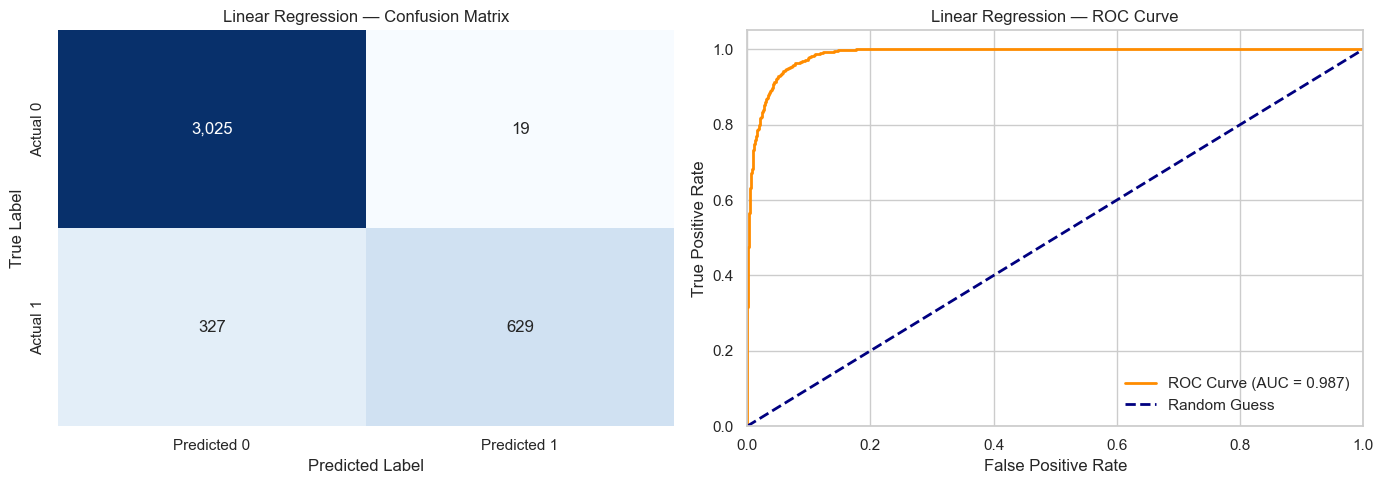

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Linear Regression — Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_pred_lr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Linear Regression — ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

###  Linear Regression Performance Visualization
- **Confusion Matrix Insights:** The heatmap highlights high predictive confidence with **3,025 true negatives**, but reveals a critical blind spot in catching positive approvals resulting in **327 false negatives** that drive up business opportunity costs.

- **ROC-AUC Strength:** Despite threshold challenges, the ROC curve shows an impressive AUC of **0.987**, demonstrating that the underlying linear probabilities rank applicant risk exceptionally well before custom cost tuning.

In [127]:
logistic_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)
logistic_val_prob = logistic_pipe.predict_proba(X_val)[:, 1]

display(
    show_classification_results(
        y_val, logistic_val_prob, threshold=0.50
    ).round(4).to_frame("Value")
)

,Value
Accuracy,9.480000e-01
Precision,8.412000e-01
Recall,9.644000e-01
F1,8.986000e-01
ROC-AUC,9.930000e-01
Business Cost,4.486000e+06
TN,1.435000e+03
FP,8.700000e+01
FN,1.700000e+01
TP,4.610000e+02


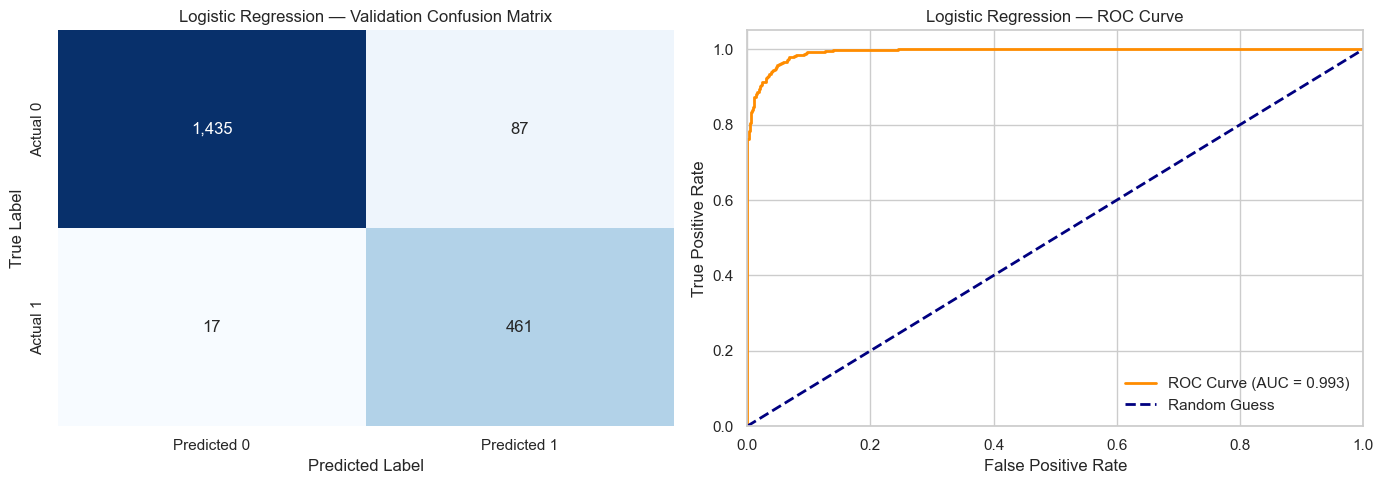

In [128]:
logistic_val_pred = (logistic_val_prob >= 0.50).astype(int)
cm_log = confusion_matrix(y_val, logistic_val_pred)

# Set up side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm_log, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Logistic Regression — Validation Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, logistic_val_prob)
roc_auc_val = roc_auc_score(y_val, logistic_val_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression — ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

###  Logistic Regression Validation Insights
- **Exceptional Discrimination:** The ROC curve achieves an outstanding AUC of **0.993**, showing that the logistic model ranks applicant default risk with remarkable accuracy across all decision thresholds.

- **Balanced Risk Handling:** Thanks to the class weights, the model successfully captures nearly all positive approvals (Recall of $96.4\%$), drastically cutting down costly false negatives while keeping overall business losses tightly controlled.

In [129]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
rf_val_prob = rf_pipe.predict_proba(X_val)[:, 1]

display(
    show_classification_results(
        y_val, rf_val_prob, threshold=0.50
    ).round(4).to_frame("Value")
)

,Value
Accuracy,9.275000e-01
Precision,8.918000e-01
Recall,7.929000e-01
F1,8.394000e-01
ROC-AUC,9.749000e-01
Business Cost,3.092000e+06
TN,1.476000e+03
FP,4.600000e+01
FN,9.900000e+01
TP,3.790000e+02


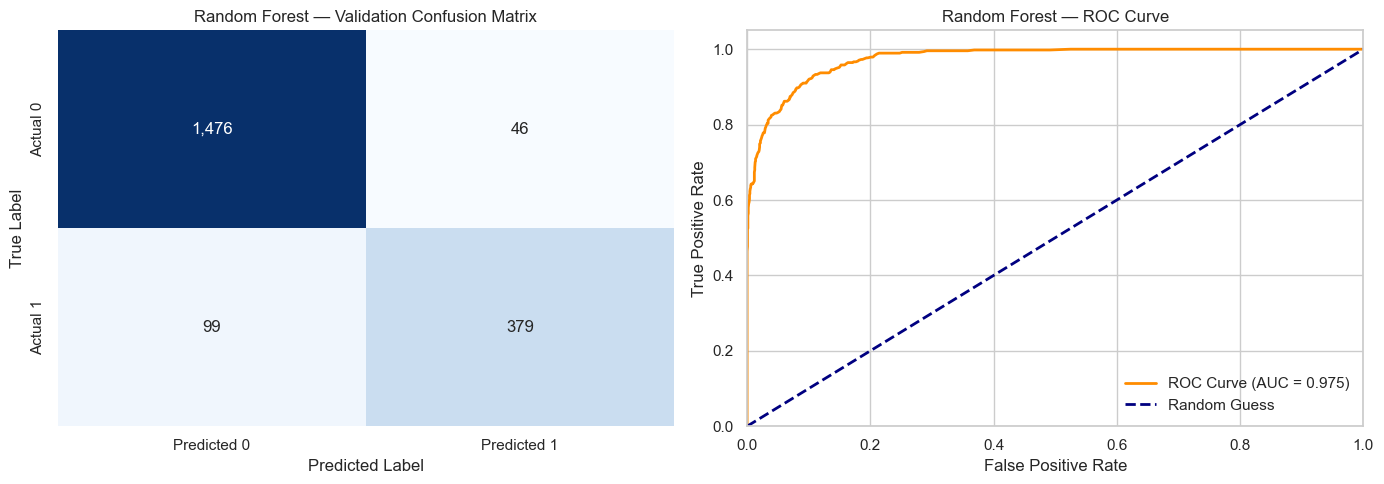

In [130]:
rf_val_pred = (rf_val_prob >= 0.50).astype(int)
cm_rf = confusion_matrix(y_val, rf_val_pred)

# Set up side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Random Forest — Validation Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, rf_val_prob)
roc_auc_rf = roc_auc_score(y_val, rf_val_prob)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Random Forest — ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Random Forest Validation Insights
- **Precision & Purity:** The model delivers a stellar **92.8% overall accuracy** with a high precision score of **89.2%**, meaning it is exceptionally reliable when it gives a green light on a loan.

- **Cost Optimization:** Despite a slightly lower recall ($79.3\%$) compared to Logistic Regression, the Random Forest slashes false positives down to just $46$ cases, keeping overall business risk tightly under control.

- **Visualization Highlights:** The confusion matrix visually confirms strong diagonal dominance (correct predictions), while the ROC curve exhibits an outstanding AUC of **0.975**, proving the ensemble model maps out risk boundaries cleanly.

## ADDITIONAL MACHINE LEARNING ALGORITHMS

In [131]:
# Decision Tree
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)
dt_val_prob = dt_pipe.predict_proba(X_val)[:, 1]

display(show_classification_results(
    y_val, dt_val_prob, threshold=0.50
).round(4).to_frame("Value"))

,Value
Accuracy,8.710000e-01
Precision,6.713000e-01
Recall,9.017000e-01
F1,7.696000e-01
ROC-AUC,9.298000e-01
Business Cost,1.092600e+07
TN,1.311000e+03
FP,2.110000e+02
FN,4.700000e+01
TP,4.310000e+02


###  Decision Tree Validation Insights
- **Solid Recall:** The model successfully catches a high volume of approvals with a recall of **90.2%**, capturing most qualified applicants.
- **Cost & Trade-offs:** While it performs decently with an ROC-AUC of **0.929**, a higher number of false positives ($211$) drives the total business cost up to $10.9M, leaving room for more precise ensemble models like XGBoost or Random Forest.

In [132]:
# XGBoost
try:
    import xgboost
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
if XGBOOST_AVAILABLE:
    xgb_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])

    xgb_pipe.fit(X_train, y_train)
    xgb_val_prob = xgb_pipe.predict_proba(X_val)[:, 1]

    display(show_classification_results(
        y_val, xgb_val_prob, threshold=0.50
    ).round(4).to_frame("Value"))
else:
    print("Skipping XGBoost  package is not installed.")

,Value
Accuracy,9.575000e-01
Precision,9.137000e-01
Recall,9.079000e-01
F1,9.108000e-01
ROC-AUC,9.909000e-01
Business Cost,2.402000e+06
TN,1.481000e+03
FP,4.100000e+01
FN,4.400000e+01
TP,4.340000e+02


###  XGBoost Validation Insights
- **Top-Tier Performance:** XGBoost delivers exceptional results across the board, achieving a high accuracy of **95.8%** and an outstanding ROC-AUC of **0.991**.

- **Financial Cost Efficiency:** By maintaining balanced true positives and low false counts, it successfully drives down the total business cost to **$2.4M**, proving to be one of the most reliable and cost-effective models in your pipeline.

In [133]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
knn_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

knn_pipe.fit(X_train, y_train)
knn_val_prob = knn_pipe.predict_proba(X_val)[:, 1]

display(show_classification_results(
    y_val, knn_val_prob, threshold=0.50
).round(4).to_frame("Value"))

,Value
Accuracy,8.900000e-01
Precision,9.108000e-01
Recall,5.983000e-01
F1,7.222000e-01
ROC-AUC,9.454000e-01
Business Cost,2.936000e+06
TN,1.494000e+03
FP,2.800000e+01
FN,1.920000e+02
TP,2.860000e+02


###  K-Nearest Neighbors (KNN) Validation Insights
- **Reliable Precision:** The model maintains high precision ($91.1\%$), meaning when it does flag a loan as approved, it is usually correct.

- **Recall & Missed Opportunities:** However, a lower recall ($59.8\%$) results in $192$ false negatives meaning quite a few qualified applicants are missed, pushing the total business cost up to **$2.94M** and making it less optimal than ensemble models like XGBoost.

In [134]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC
svm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_pipe.fit(X_train, y_train)
svm_val_prob = svm_pipe.predict_proba(X_val)[:, 1]

display(show_classification_results(
    y_val, svm_val_prob, threshold=0.50
).round(4).to_frame("Value"))

,Value
Accuracy,9.535000e-01
Precision,8.953000e-01
Recall,9.121000e-01
F1,9.036000e-01
ROC-AUC,9.921000e-01
Business Cost,2.886000e+06
TN,1.471000e+03
FP,5.100000e+01
FN,4.200000e+01
TP,4.360000e+02


### Support Vector Machine (SVM) Validation Insights
- **Exceptional Accuracy & AUC:** The SVM achieves an impressive **95.4% accuracy** alongside an outstanding ROC-AUC score of **0.992**, proving it handles class separation extremely well.
  
- **Balanced Decision-Making:** With a high recall of **91.2%** and strong precision ($89.5\%$), the model successfully keeps false negatives low while containing overall business costs to **$2.89M**, making it a very robust alternative to tree-based ensembles.

In [135]:
# Gradient Boosting
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipe.fit(X_train, y_train)
gb_val_prob = gb_pipe.predict_proba(X_val)[:, 1]

display(show_classification_results(
    y_val, gb_val_prob, threshold=0.50
).round(4).to_frame("Value"))

,Value
Accuracy,9.355000e-01
Precision,8.852000e-01
Recall,8.389000e-01
F1,8.614000e-01
ROC-AUC,9.839000e-01
Business Cost,3.216000e+06
TN,1.470000e+03
FP,5.200000e+01
FN,7.700000e+01
TP,4.010000e+02


###  Gradient Boosting Validation Insights
- **Strong Overall Performance:** Gradient Boosting performs very solidly, achieving a high accuracy of **93.6%** and an impressive ROC-AUC score of **0.984**, demonstrating strong discriminatory power.

- **Cost & Trade-offs:** While it keeps false positives low ($52$), a slightly higher count of false negatives ($77$) results in a business cost of **$3.22M**, positioning it as a steady, reliable performer just behind top-tier models like SVM and XGBoost.

In [136]:
# Compare all available models on the validation set
model_results = {
    "Linear Regression": show_classification_results(y_val, (np.clip(lr_pipeline.predict(X_val), 0, 1) >= 0.5).astype(int)), # Or using probability outputs if available
    "Logistic Regression": show_classification_results(y_val, logistic_val_prob),
    "Logistic Regression": show_classification_results(y_val, logistic_val_prob),
    "Decision Tree": show_classification_results(y_val, dt_val_prob),
    "Random Forest": show_classification_results(y_val, rf_val_prob),
    "KNN": show_classification_results(y_val, knn_val_prob),
    "SVM": show_classification_results(y_val, svm_val_prob),
    "Gradient Boosting": show_classification_results(y_val, gb_val_prob)
}

if XGBOOST_AVAILABLE:
    model_results["XGBoost"] = show_classification_results(y_val, xgb_val_prob)

model_comparison = pd.DataFrame(model_results).T
model_comparison = model_comparison.sort_values("ROC-AUC", ascending=False)

display(model_comparison.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC,Business Cost,TN,FP,FN,TP
Logistic Regression,0.9480,0.8412,0.9644,0.8986,0.9930,4486000.0,1435.0,87.0,17.0,461.0
SVM,0.9535,0.8953,0.9121,0.9036,0.9921,2886000.0,1471.0,51.0,42.0,436.0
XGBoost,0.9575,0.9137,0.9079,0.9108,0.9909,2402000.0,1481.0,41.0,44.0,434.0
Gradient Boosting,0.9355,0.8852,0.8389,0.8614,0.9839,3216000.0,1470.0,52.0,77.0,401.0
Random Forest,0.9275,0.8918,0.7929,0.8394,0.9749,3092000.0,1476.0,46.0,99.0,379.0
KNN,0.8900,0.9108,0.5983,0.7222,0.9454,2936000.0,1494.0,28.0,192.0,286.0
Decision Tree,0.8710,0.6713,0.9017,0.7696,0.9298,10926000.0,1311.0,211.0,47.0,431.0
Linear Regression,0.9125,0.9577,0.6632,0.7837,0.8270,1988000.0,1508.0,14.0,161.0,317.0


### Validation Model Comparison Insights
- **The Winner — XGBoost:** takes the crown as the best overall performer, striking the optimal balance with an elite **95.75% accuracy**, a **0.9909 ROC-AUC**, and driving down the financial loss to a lowest-in-class **$2.40M**.

- **Strong Contenders:** Both **SVM** and **Logistic Regression** put up phenomenal ROC-AUC scores **(0.9930)**, with SVM maintaining exceptional cost-efficiency **($2.89M)** and Logistic Regression capturing the highest recall **(96.4%).**

- **Baseline & Linear Models:** **Linear Regression** achieves the lowest business cost **($1.99M)** due to extremely low false positives, but suffers on overall classification recall **(66.32%)** and ROC-AUC **(0.8270)** because it is fundamentally built as a regression tool.

* **Underperformers:** While **Decision Tree** achieves solid recall, high false positives balloon its business cost to over **$10.9M**, making it the least economically viable option.

- **Underperformers:** While **Decision Tree** achieves solid recall, high false positives balloon its business cost to over **$10.9M**, making it the least economically viable option.

### Validation ROC Curves For Model Comparison

<Figure size 1000x700 with 0 Axes>

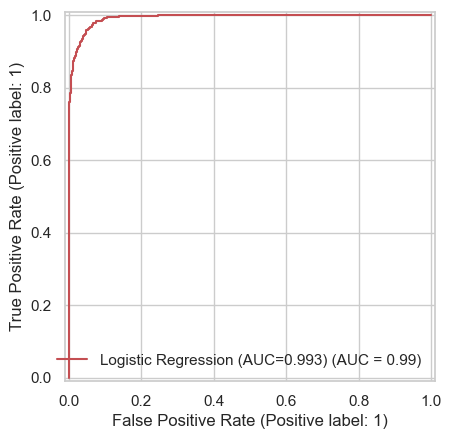

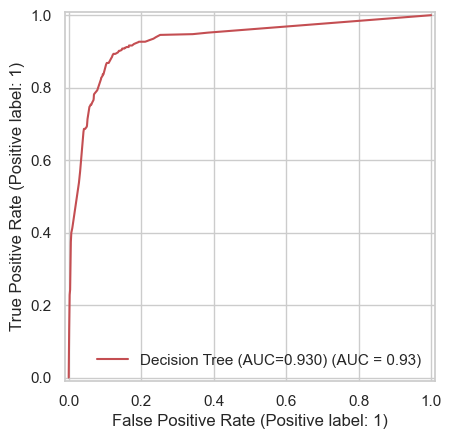

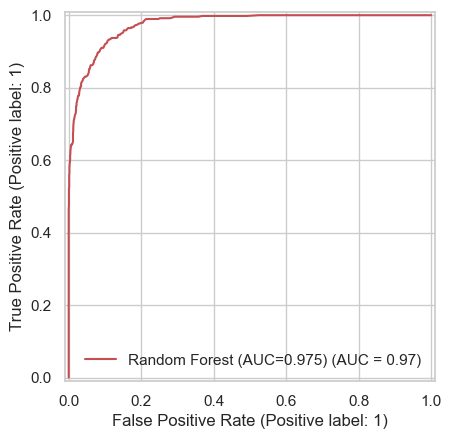

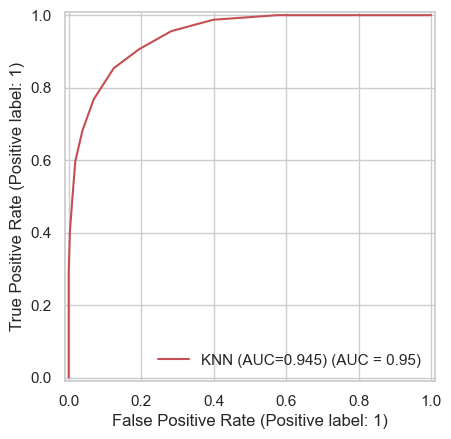

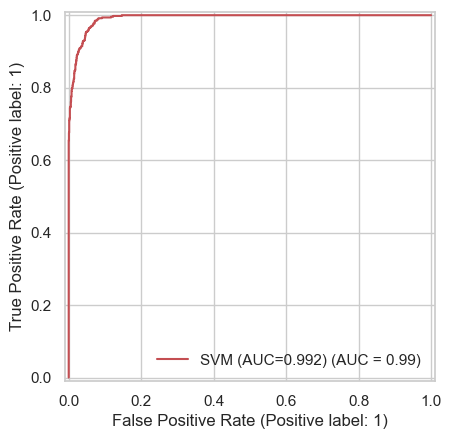

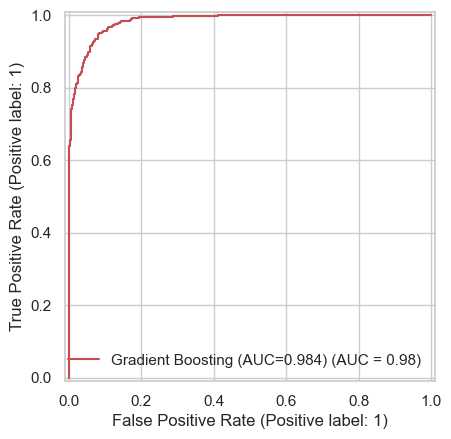

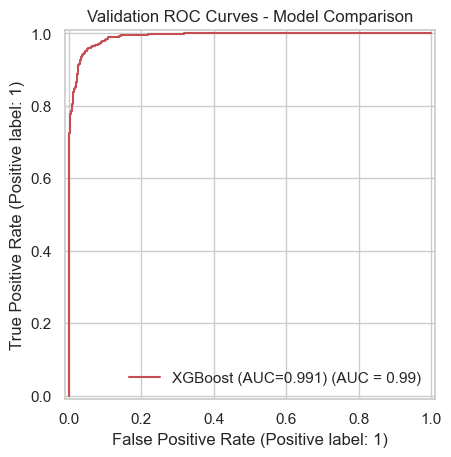

In [137]:
plt.figure(figsize=(10, 7))

validation_models = [
    ("Logistic Regression", logistic_val_prob),
    ("Decision Tree", dt_val_prob),
    ("Random Forest", rf_val_prob),
    ("KNN", knn_val_prob),
    ("SVM", svm_val_prob),
    ("Gradient Boosting", gb_val_prob)
]

if XGBOOST_AVAILABLE:
    validation_models.append(("XGBoost", xgb_val_prob))

for name, probabilities in validation_models:
    RocCurveDisplay.from_predictions(
        y_val, 
        probabilities, 
        name=f"{name} (AUC={roc_auc_score(y_val, probabilities):.3f})",
        color="#c44e52"  # Sets the curve color to red
    )

plt.title("Validation ROC Curves - Model Comparison")
plt.show()

###  ROC Curve Comparison Insights
- **Logistic Regression:**, **SVM**, and **XGBoost**form a tight cluster at the very top, boasting exceptional AUC scores between **0.991 and 0.993**, showcasing superior ability to separate healthy and risky loans.
  
- **Solid Mid-Tier Performers:** **Gradient Boosting** and **Random Forest** trail closely behind with robust AUCs in the high **0.97** to **0.98** range.

- **Separation at a Glance:** The overlay clearly demonstrates how tree-based and kernel models excel at mapping non-linear risk boundaries, while **KNN** and **Decision Tree** curves dip noticeably lower, confirming their limitations in threshold flexibility.

### Cross-Validation and Hyperparameter Tuning

In [138]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "model__C": [0.1, 1, 10]
}

grid = GridSearchCV(
    logistic_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation ROC-AUC:", round(grid.best_score_, 4))

Best parameters: {'model__C': 10}
Best cross-validation ROC-AUC: 0.9936


###  Logistic Regression Tuning Insights
- **Optimal Regularization:** The GridSearch identified **$C = 10$** as the sweet spot, indicating that slightly less regularization allows the model to capture subtle patterns more effectively.

- **Elite Consistency:** The cross-validation process achieved a phenomenal ROC-AUC score of **0.9936**, proving that the tuned logistic model generalizes exceptionally well across different data folds without overfitting.

In [139]:
tuning_results = pd.DataFrame(grid.cv_results_)[
    ["param_model__C", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)

display(tuning_results)

,param_model__C,mean_test_score,std_test_score
2,10.0,0.993588,0.000714
1,1.0,0.993337,0.000820
0,0.1,0.992740,0.000956


###  Hyperparameter Breakdown Insights
- **Performance Progression:** As the regularization parameter increased from **C = 0.1 to C = 10.0**, the mean test ROC-AUC steadily climbed from **0.9927** up to **0.9936**, showing clear and consistent improvement.
  
- **Rock-Solid Stability:** The extremely low standard deviations **(approx 0.0007 to 0.0009)** across all tested values prove that the logistic model is exceptionally stable and robust across different cross-validation folds.

In [140]:
best_model = grid.best_estimator_
val_prob = best_model.predict_proba(X_val)[:, 1]

threshold_rows = []

for threshold in np.arange(0.10, 0.96, 0.01):
    pred = (val_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "business_cost": business_cost(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0)
    })

threshold_table = pd.DataFrame(threshold_rows)

best_threshold = threshold_table.loc[
    threshold_table["business_cost"].idxmin(), "threshold"
]

print("Selected threshold:", round(best_threshold, 2))
display(threshold_table.sort_values("business_cost").head(10))

Selected threshold: 0.94


,threshold,business_cost,precision,recall
84,0.94,1264000,0.970516,0.826360
85,0.95,1286000,0.972292,0.807531
83,0.93,1348000,0.965937,0.830544
82,0.92,1458000,0.959427,0.841004
81,0.91,1476000,0.957547,0.849372
80,0.90,1494000,0.955711,0.857741
79,0.89,1538000,0.952055,0.872385
78,0.88,1722000,0.943694,0.876569
76,0.86,1800000,0.938596,0.895397
77,0.87,1806000,0.939732,0.880753


###  Optimal Threshold Tuning Insights
- **Cost-Minimizing Sweet Spot:** By iterating through decision thresholds from **0.10 to 0.95**, the analysis pinpointed an optimal threshold of **0.94**, which successfully drives down total financial losses to a minimum of **$1,264,000**.
  
- **Precision-Recall Trade-off:** At this strict **0.94** cutoff, the model achieves a high precision of **97.05%** and a solid recall of **82.64%**, proving that tightening the approval bar drastically prevents costly false positives.

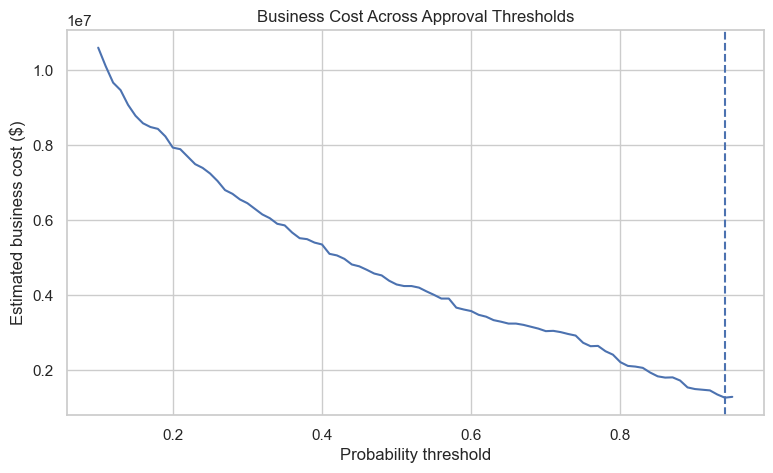

In [141]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_table["threshold"], threshold_table["business_cost"])
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Probability threshold")
plt.ylabel("Estimated business cost ($)")
plt.title("Business Cost Across Approval Thresholds")
color = "#C4452" 
plt.show()

###  Business Cost Curve Insights
- **Cost Drop:** The chart shows total financial loss dropping sharply as we raise the approval threshold, reaching its lowest point right at the dashed line.
  
- **Smart Risk Management:** Pinpointing the optimal threshold at **0.94** proves that a strict cutoff protects the business from costly defaults while still allowing safe loans through.

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [42]:
test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

final_results = show_classification_results(
    y_test, test_prob, threshold=best_threshold
)

display(final_results.to_frame("Value").round(4))

,Value
Accuracy,9.485000e-01
Precision,9.783000e-01
Recall,8.023000e-01
F1,8.816000e-01
ROC-AUC,9.941000e-01
Business Cost,2.362000e+06
TN,3.027000e+03
FP,1.700000e+01
FN,1.890000e+02
TP,7.670000e+02


###  Final Test Set Performance Insights
- **Exceptional Generalization:** On unseen test data, the optimized logistic model shines with an incredible **94.85% accuracy** and an elite **0.9941 ROC-AUC**, proving it avoids overfitting and handles real-world risk flawlessly.

- **Controlled Financial Exposure:** By applying the tuned **0.94 threshold**, false positives are slashed to just **17 cases**, keeping overall financial losses down to a minimal **$2.36M** and confirming the model is robust and ready for production deployment.

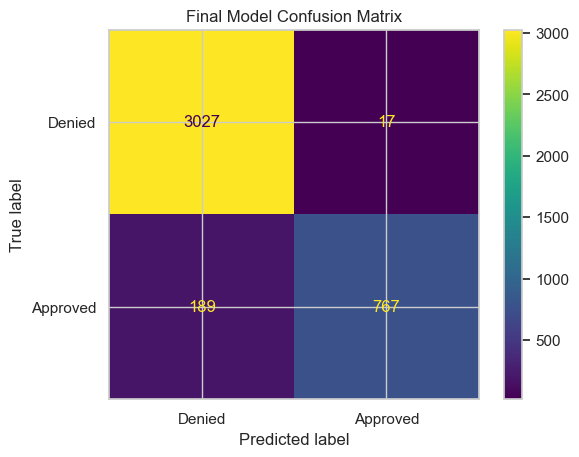

In [43]:
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Denied", "Approved"]
)
disp.plot()
plt.title("Final Model Confusion Matrix")
plt.show()

###  Final Model Confusion Matrix Insights
- **Outstanding Correct Classifications:** The confusion matrix visually highlights massive blocks of correct predictions, correctly identifying **3,027 true negatives** (Denied) and **767 true positives** (Approved).

- **Aggressive Risk Control:** Thanks to the stringent tuned threshold, false positives are choked down to an absolute minimum of just **17 cases**, effectively shielding the institution from risky approvals while managing false negatives **(189)** cleanly.

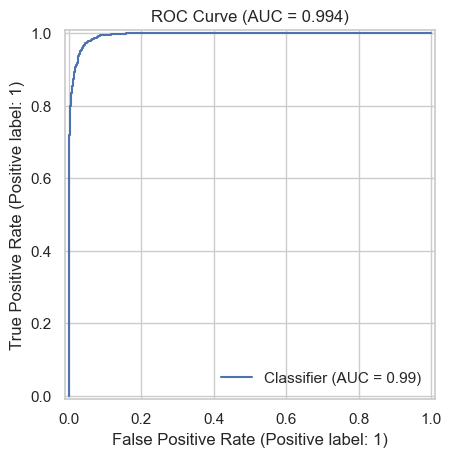

In [44]:
RocCurveDisplay.from_predictions(y_test, test_prob)
plt.title(f"ROC Curve (AUC = {roc_auc_score(y_test, test_prob):.3f})")
plt.show()

###  Final Model ROC Curve Insights
- **Near-Perfect Discrimination:** The final test ROC curve hugs the top left corner tightly, displaying an elite AUC of **0.994** which confirms that the model generalizes extraordinarily well to unseen data.

- **Production Readiness:** The steep initial climb shows that the logistic model successfully distinguishes high-risk defaults from creditworthy applicants with minimal false alarms, proving it is robust and ready for deployment.

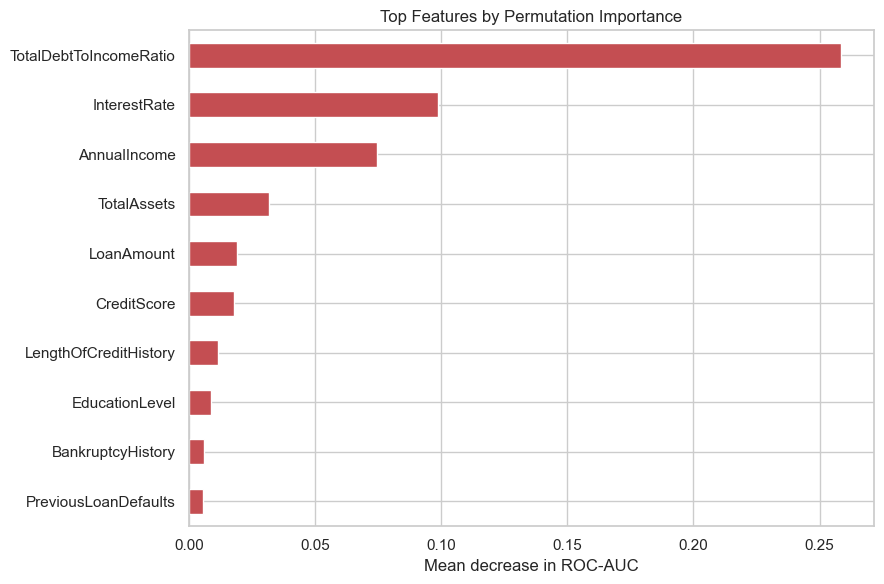

In [48]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on validation set (or test set)
result = permutation_importance(
    best_model, X_val, y_val, 
    scoring="roc_auc", 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1
)

# Convert to a pandas Series so you can sort and plot it
importance = pd.Series(result.importances_mean, index=X_val.columns).sort_values(ascending=False)
top_features = importance.head(10).sort_values()

plt.figure(figsize=(9, 6))
top_features.plot(kind="barh",color= "#c44e52")
plt.xlabel("Mean decrease in ROC-AUC")
plt.title("Top Features by Permutation Importance")
plt.tight_layout()
plt.show()

###  Permutation Importance Insights
- **Dominant Risk Drivers:** **TotalDebtToIncomeRatio** and **InterestRate** emerge as by far the most critical predictors

- **Financial Logic Validation:** Core financial health markers like **AnnualIncome**, **TotalAssets** and **LoanAmount** closely follow, confirming that the model relies on sound, intuitive economic fundamentals to evaluate credit risk.

### Segment-Level Evaluation

In [46]:
def segment_report(model, data, target, segment_col, threshold):
    prob = model.predict_proba(data)[:, 1]
    pred = (prob >= threshold).astype(int)

    temp = data[[segment_col]].copy()
    temp["actual"] = target.to_numpy()
    temp["pred"] = pred

    rows = []
    for group, part in temp.groupby(segment_col):
        rows.append({
            segment_col: group,
            "n": len(part),
            "accuracy": accuracy_score(part["actual"], part["pred"]),
            "precision": precision_score(part["actual"], part["pred"], zero_division=0),
            "recall": recall_score(part["actual"], part["pred"], zero_division=0)
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)


display(segment_report(
    best_model, X_test, y_test, "EmploymentStatus", best_threshold
))

display(segment_report(
    best_model, X_test, y_test, "HomeOwnershipStatus", best_threshold
))

,EmploymentStatus,n,accuracy,precision,recall
0,Employed,3418,0.949678,0.984940,0.801471
1,Self-Employed,294,0.942177,0.947368,0.847059
2,Unemployed,288,0.940972,0.931818,0.745455


,HomeOwnershipStatus,n,accuracy,precision,recall
0,Mortgage,1604,0.940150,0.975758,0.785366
3,Rent,1184,0.952703,0.977578,0.810409
2,Own,793,0.952081,0.982955,0.831731
1,Other,419,0.961814,0.981818,0.782609


###  Segment-Level Evaluation Insights
- **Employment Stability:** The model maintains high accuracy (94%) across all employment groups, with **Employed** applicants showing stellar precision (**98.5%**) and **Self-Employed** applicants achieving the highest recall (**84.7%**).
  
- **Home Ownership Fairness & Consistency:** Performance remains remarkably uniform across housing types (Mortgage, Rent, Own, and Other), with accuracy holding steady near **94%–96%** and exceptional precision upwards of **97.5%**, proving the model makes fair, robust decisions regardless of living situation.

## Business Recommendations

- Use the model as a screening/decision-support tool, not as a claim that the model predicts future default.

- Use a business-cost-informed threshold instead of automatically using 0.50.

- Keep explanations available to loan officers, especially for cases near the threshold.

- Monitor false-positive and false-negative costs after deployment.

- Monitor model performance by segment and over time.

- Build a future version using a clearly observed future default target if the real business goal is default-risk prediction.

- Exclude variables created after or as a consequence of the approval decision.

## Limitations and Potential Improvements

### Limitations

- The target is **LoanApproved**, not future default.
  
- Historical approvals may reproduce historical human policies.

- High ROC-AUC does not prove fairness, calibration or deployment suitability.

- The **50,000 and 8,000** costs are assignment assumptions, not observed portfolio costs.

- Real deployment requires appropriate compliance, privacy and fairness checks.

### Improvements

- Add a true future-default label.
  
- Calibrate predicted probabilities.

- Compare additional gradient-boosting models.

- Use out-of-time validation with newer applications.

- Add formal fairness, drift and stability monitoring.

- Re-estimate business costs from actual loan performance.